In [1]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

In [2]:
def cov(Ns, dt, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=dt)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.toeplitz(cov0)

In [3]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

In [4]:
Cov = cov(30, 5e-9, A, omega0, gamma, p, C)

In [5]:
Cov.shape

(30, 30)

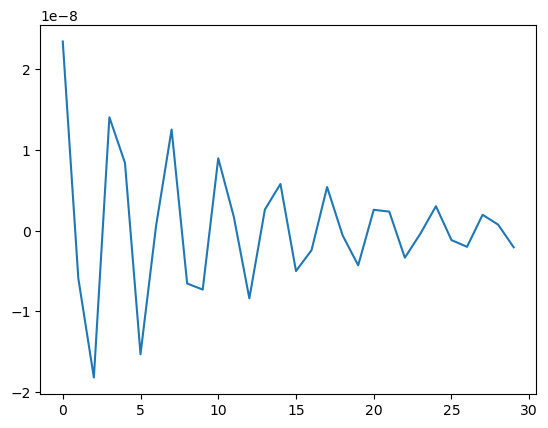

In [6]:
plt.plot(Cov[0])
plt.show()

In [7]:
cov_1ns = cov(150, 1e-9, A, omega0, gamma, p, C)

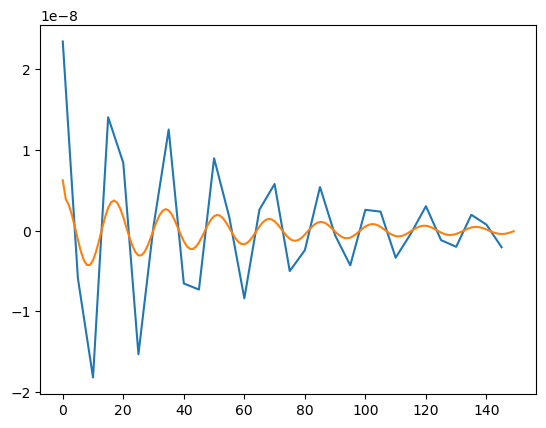

In [8]:
plt.plot(np.arange(30)*5,Cov[0])
plt.plot(cov_1ns[0])
plt.show()

In [27]:
def cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.toeplitz(cov0)

In [30]:
Cov = cov(500, A, omega0, gamma, p, C)

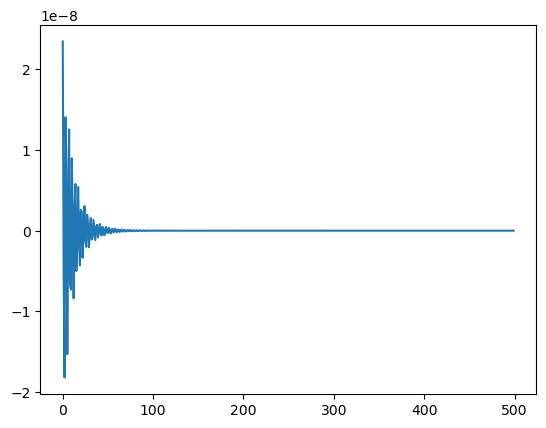

In [31]:
plt.plot(Cov[0])
plt.show()

In [12]:
seed = 45
key, subkey = random.split(random.PRNGKey(seed))

a = jft.NormalPrior(mean=0, std=1, shape=(150,), name="input")

xi = jft.random_like(subkey, a.domain)

In [13]:
latent_sample = xi["input"]

In [14]:
latent_sample

Array([ 1.9180208e-01,  1.7461933e+00,  1.1431401e+00,  9.5439911e-01,
       -9.5342153e-01, -3.7014183e-01,  3.2377115e-01, -1.3228760e+00,
        1.0857606e+00,  1.1462193e+00, -2.9842633e-01, -7.4605739e-01,
       -3.5558436e-02, -3.8187864e-01,  1.1191795e+00, -1.5680355e+00,
       -1.6446087e+00,  6.3437021e-01, -4.9469388e-01,  1.4544804e+00,
        3.8840330e-01,  9.7231662e-01, -8.2733959e-04, -6.8521619e-01,
       -1.3215718e+00,  7.4683768e-01,  5.9171343e-01,  7.2699022e-01,
        4.2041764e-01,  2.4844296e-01,  8.3792061e-02,  3.2888514e-01,
       -1.3585100e+00,  2.2107410e+00, -9.4506055e-01,  8.6534548e-01,
        9.9004108e-01, -2.1175693e-01, -4.9268380e-01,  6.6857338e-01,
       -2.5148663e-01, -1.4169184e+00,  1.1638444e-01, -7.8950882e-01,
       -5.5329597e-01,  7.8025717e-01,  2.9972076e-01, -9.7550547e-01,
       -1.0213413e+00, -6.1269578e-02, -6.1059362e-01, -7.8046811e-01,
       -5.2353990e-01, -6.8935835e-01, -6.7986804e-01, -6.6427380e-01,
      

In [15]:
z = a(xi)

In [16]:
z

Array([ 1.9180208e-01,  1.7461933e+00,  1.1431401e+00,  9.5439911e-01,
       -9.5342153e-01, -3.7014183e-01,  3.2377115e-01, -1.3228760e+00,
        1.0857606e+00,  1.1462193e+00, -2.9842633e-01, -7.4605739e-01,
       -3.5558436e-02, -3.8187864e-01,  1.1191795e+00, -1.5680355e+00,
       -1.6446087e+00,  6.3437021e-01, -4.9469388e-01,  1.4544804e+00,
        3.8840330e-01,  9.7231662e-01, -8.2733959e-04, -6.8521619e-01,
       -1.3215718e+00,  7.4683768e-01,  5.9171343e-01,  7.2699022e-01,
        4.2041764e-01,  2.4844296e-01,  8.3792061e-02,  3.2888514e-01,
       -1.3585100e+00,  2.2107410e+00, -9.4506055e-01,  8.6534548e-01,
        9.9004108e-01, -2.1175693e-01, -4.9268380e-01,  6.6857338e-01,
       -2.5148663e-01, -1.4169184e+00,  1.1638444e-01, -7.8950882e-01,
       -5.5329597e-01,  7.8025717e-01,  2.9972076e-01, -9.7550547e-01,
       -1.0213413e+00, -6.1269578e-02, -6.1059362e-01, -7.8046811e-01,
       -5.2353990e-01, -6.8935835e-01, -6.7986804e-01, -6.6427380e-01,
      

# Generating Noise from Covariance matrix

Assume the covariance matrix is symmetric and positive (semi)definite.\
I have a sample where
$$ z \sim N(0, I)$$
which is from Gaussian Distribution. \
`z=a(xi)`

Then, 
$$ Cov(z) = E[zz^{T}]=I$$

At the same time, for a physical noise with the size of $\Sigma$, denoted as $n$, 
$$ \Sigma = Cov(n) = E[nn^{T}] $$

Here, Cholesky Decomposition produces $L$ s.t.
$\Sigma = L L^{T}$

Hence,
$$\Sigma = LIL^{T} = E[Lzz^{T}L[T]] = E[n n^{T}]$$
meaning
$$n = Lz $$

To recover $z$, then,
$$ z = L^{-1} n$$

In [17]:
# Check if cov is PSD
eig = np.linalg.eigvalsh(Cov)
eig.min()

np.float32(4.7143015e-11)

In [18]:
L = jax.scipy.linalg.cholesky(Cov)
n = L @ z

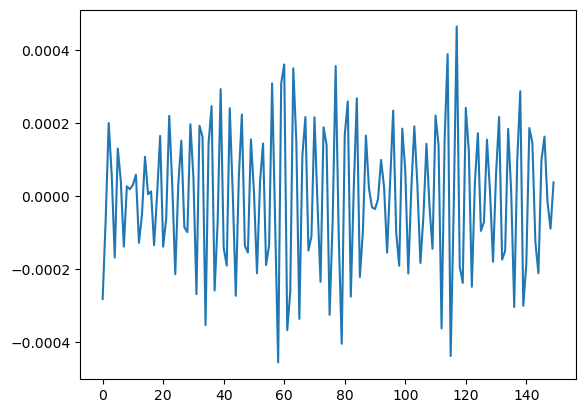

In [19]:
plt.plot(n)
plt.show()

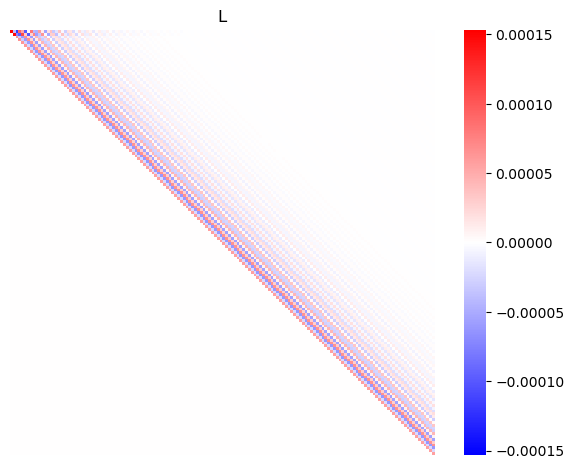

In [20]:
plt.figure()
sns.heatmap(L, xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
plt.title(f"L")
plt.tight_layout()
plt.show()

In [21]:
L_1 = jax.scipy.linalg.inv(L)

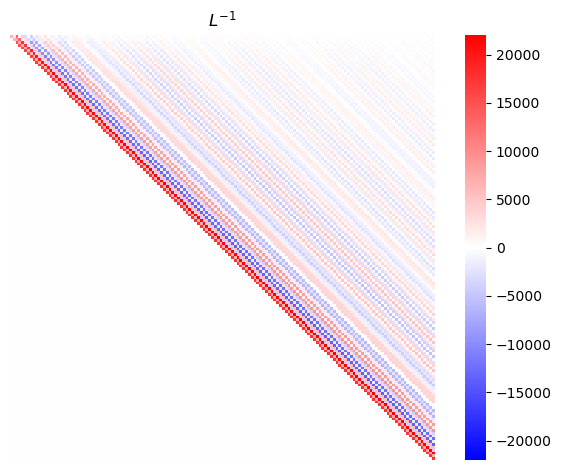

In [22]:
plt.figure()
sns.heatmap(L_1, xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
plt.title(r"$L^{-1}$")
plt.tight_layout()
plt.show()

In [23]:
z_rec = jax.scipy.linalg.solve(L, n)

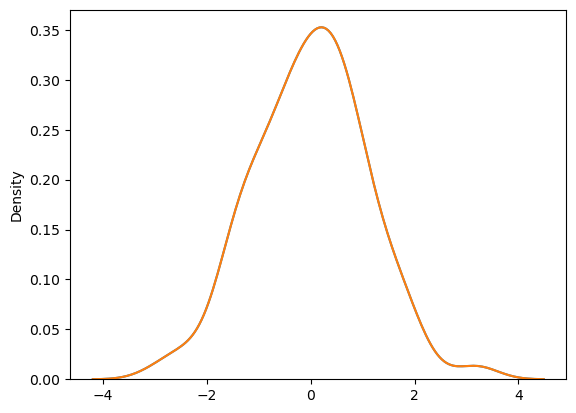

In [24]:
sns.kdeplot(z)
sns.kdeplot(z_rec)
plt.show()

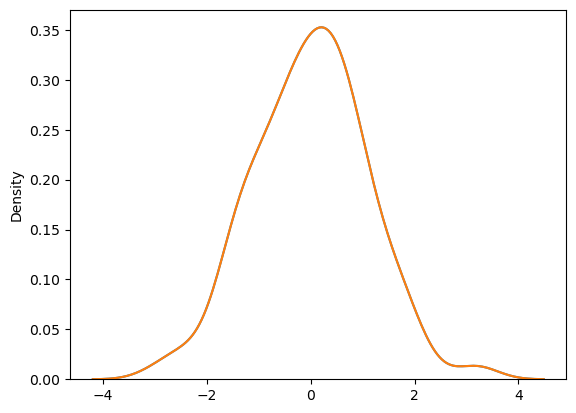

In [25]:
z_rec_inv = L_1 @ n
sns.kdeplot(z)
sns.kdeplot(z_rec_inv)
plt.show()

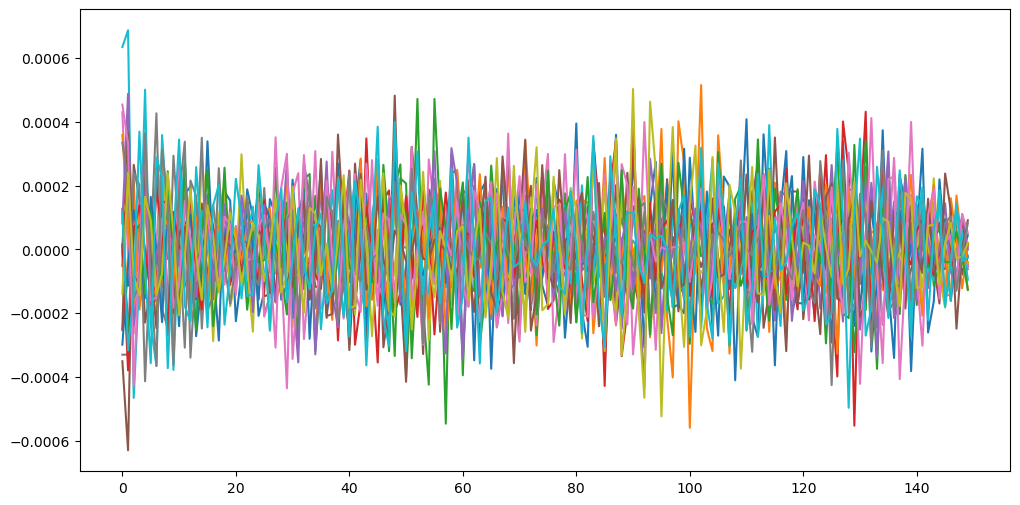

In [26]:
noises = []
a = jft.NormalPrior(mean=0, std=1, shape=(150,), name="input")
plt.figure(figsize=(12,6))
for i in range(20):
    key, subkey = random.split(random.PRNGKey(seed*2*i))
    xi = jft.random_like(subkey, a.domain)
    n = L @ a(xi)
    plt.plot(n)

plt.show()

